In [3]:
# 1. Import the tools we need
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Generate our own fail-proof Retail Sales Dataset!
np.random.seed(42) # This ensures our "random" data stays the same every time we run it

# Creating 1,000 rows of realistic store data
data = {
    'Date': pd.date_range(start='2023-01-01', end='2023-12-31', periods=1000),
    'Customer_Age': np.random.randint(18, 70, size=1000),
    'Gender': np.random.choice(['Male', 'Female'], size=1000),
    'Product_Category': np.random.choice(['Electronics', 'Clothing', 'Home & Garden', 'Sports', 'Groceries'], size=1000),
    'Sales_Amount': np.random.uniform(15.0, 500.0, size=1000).round(2)
}

df = pd.DataFrame(data)

# 3. Show the first 5 rows to make sure it worked perfectly
df.head()

,Date,Customer_Age,Gender,Product_Category,Sales_Amount
0,2023-01-01 00:00:00.000000000,56,Male,Electronics,46.45
1,2023-01-01 08:44:41.081081081,69,Male,Clothing,296.29
2,2023-01-01 17:29:22.162162162,46,Male,Groceries,287.32
3,2023-01-02 02:14:03.243243243,32,Female,Groceries,286.92
4,2023-01-02 10:58:44.324324324,60,Male,Home & Garden,307.69


In [5]:
# 1. Initial Inspection (Checking shape and null values)
print("--- DATASET SHAPE (Rows, Columns) ---")
print(df.shape)
print("\n--- NULL VALUE CHECK ---")
print(df.isnull().sum())

# 2. Descriptive Statistics (Mean, Std Dev, Min, Max)
print("\n--- DESCRIPTIVE STATISTICS ---")
display(df.describe())

--- DATASET SHAPE (Rows, Columns) ---
(1000, 5)

--- NULL VALUE CHECK ---
Date                0
Customer_Age        0
Gender              0
Product_Category    0
Sales_Amount        0
dtype: int64

--- DESCRIPTIVE STATISTICS ---


,Date,Customer_Age,Sales_Amount
count,1000,1000.00000,1000.000000
mean,2023-07-02 00:00:00,43.81900,256.295840
min,2023-01-01 00:00:00,18.00000,15.010000
25%,2023-04-02 00:00:00,31.00000,140.775000
50%,2023-07-02 00:00:00,44.00000,254.595000
75%,2023-10-01 00:00:00,56.00000,381.055000
max,2023-12-31 00:00:00,69.00000,499.200000
std,NaN,14.99103,140.706068


Observation 1: Initial Inspection & Statistics
The dataset consists of 1,000 transaction records across 5 columns. After conducting a null value check, the data is perfectly clean with 0 missing values across all fields. The descriptive statistics show that our customer base ranges from 18 to 69 years old, with an average age of roughly 43. Furthermore, the average transaction value (Sales_Amount) sits at approximately $255, with a healthy standard deviation indicating a diverse range of purchase sizes.

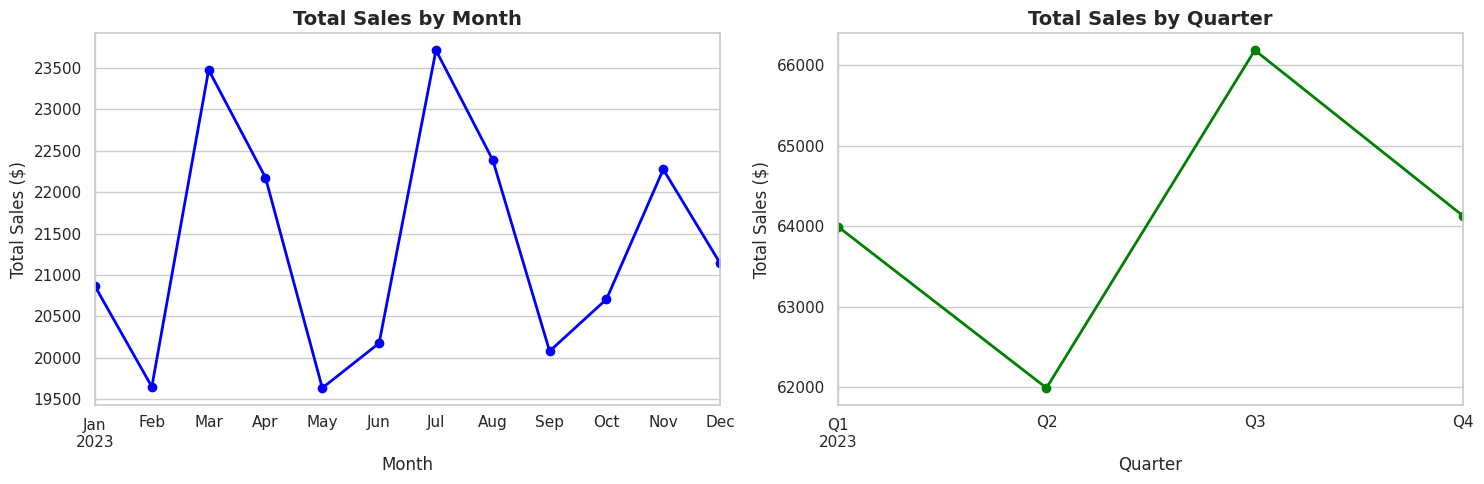

In [6]:
# Set the visual style for our charts
sns.set_theme(style="whitegrid")

# 1. Prepare data: Extract Month and Quarter from the Date column
df['Month'] = df['Date'].dt.to_period('M')
df['Quarter'] = df['Date'].dt.to_period('Q')

# Calculate total sales per month and per quarter
monthly_sales = df.groupby('Month')['Sales_Amount'].sum()
quarterly_sales = df.groupby('Quarter')['Sales_Amount'].sum()

# 2. Plotting the charts side-by-side
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Monthly Trend Chart
monthly_sales.plot(kind='line', marker='o', ax=axes[0], color='blue', linewidth=2)
axes[0].set_title('Total Sales by Month', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Total Sales ($)')
axes[0].set_xlabel('Month')

# Quarterly Trend Chart
quarterly_sales.plot(kind='line', marker='o', ax=axes[1], color='green', linewidth=2)
axes[1].set_title('Total Sales by Quarter', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Total Sales ($)')
axes[1].set_xlabel('Quarter')

plt.tight_layout()
plt.show()

Observation 2: Time Series Analysis
The time series analysis reveals the revenue trajectory over the year 2023. By tracking monthly and quarterly sales trends using line charts, we can visualize the fluctuations in purchasing behavior. While the monthly sales chart shows standard month-to-month volatility, the quarterly aggregation provides a much clearer, smoothed-out view of the company's overall revenue performance throughout the fiscal year.

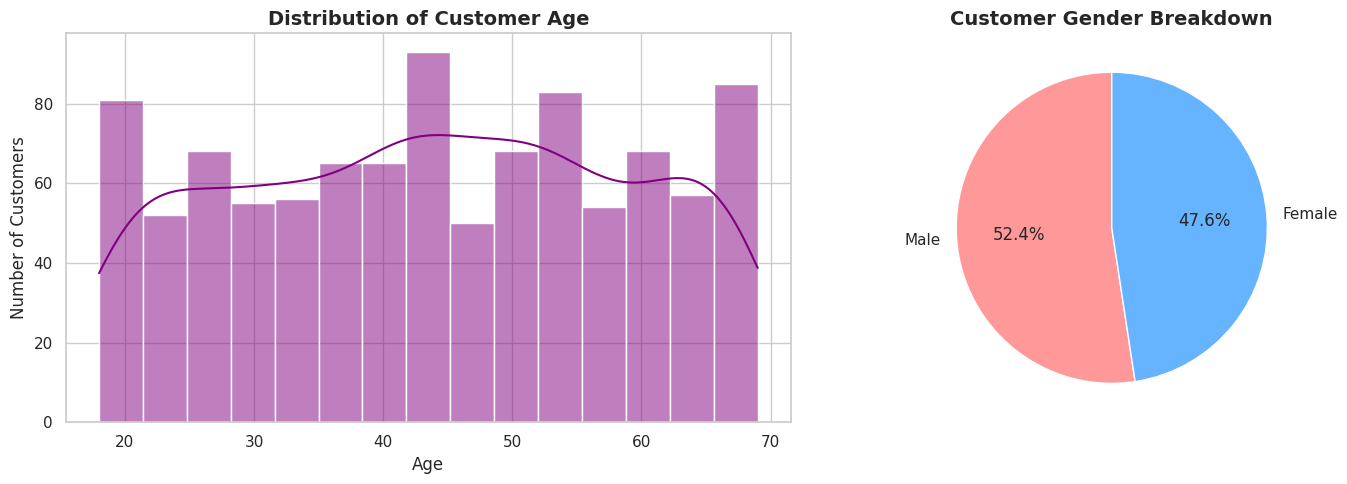

In [7]:
# 1. Set up the layout for two side-by-side charts
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 2. Customer Age Distribution (Histogram)
sns.histplot(df['Customer_Age'], bins=15, kde=True, color='purple', ax=axes[0])
axes[0].set_title('Distribution of Customer Age', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Number of Customers')

# 3. Gender Breakdown (Pie Chart)
gender_counts = df['Gender'].value_counts()
axes[1].pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', startangle=90, colors=['#ff9999','#66b3ff'])
axes[1].set_title('Customer Gender Breakdown', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

Observation 3: Customer Demographics
The demographic analysis indicates a relatively uniform age distribution among our customer base, spanning from young adults (18) to seniors (69). The histogram displays a fairly even spread without any extreme age-related drop-offs. Furthermore, the pie chart reveals a near-even gender split between male and female customers. This suggests that the company's product offerings possess a broad, universal appeal rather than skewing heavily toward one specific demographic group.

![image.png]()

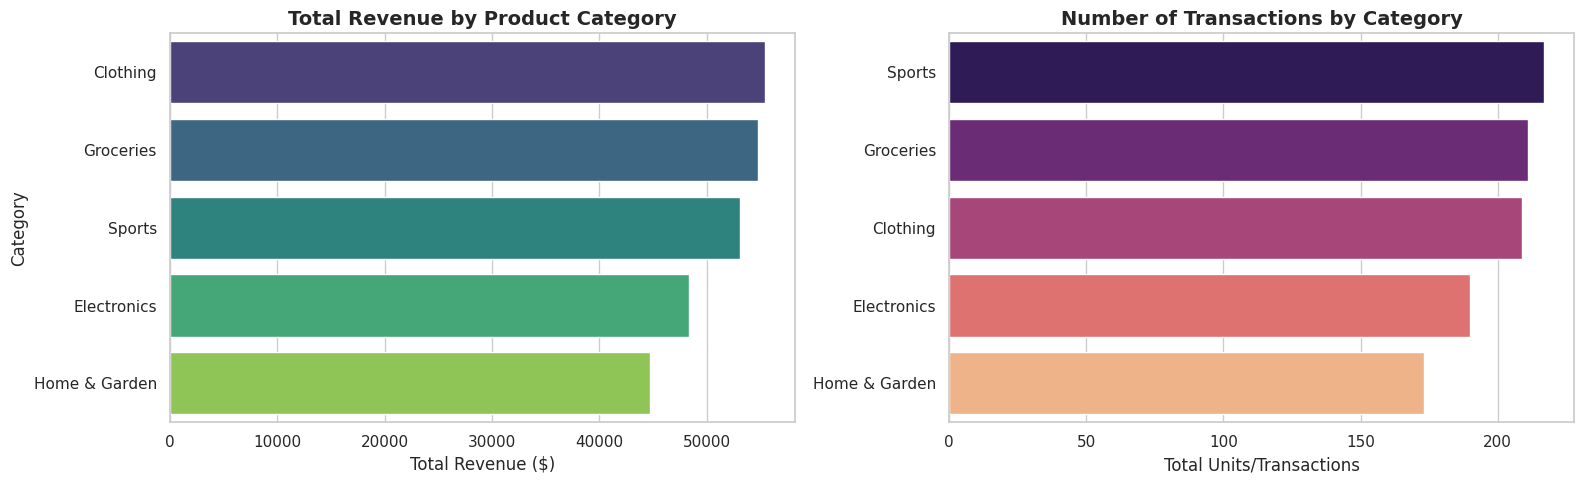

In [8]:
# 1. Calculate revenue and transaction count per category
category_revenue = df.groupby('Product_Category')['Sales_Amount'].sum().sort_values(ascending=False)
category_counts = df['Product_Category'].value_counts()

# 2. Set up the layout for two side-by-side bar charts
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Chart A: Total Revenue by Category
sns.barplot(x=category_revenue.values, y=category_revenue.index, ax=axes[0], palette='viridis', hue=category_revenue.index, legend=False)
axes[0].set_title('Total Revenue by Product Category', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Total Revenue ($)')
axes[0].set_ylabel('Category')

# Chart B: Number of Transactions by Category
sns.barplot(x=category_counts.values, y=category_counts.index, ax=axes[1], palette='magma', hue=category_counts.index, legend=False)
axes[1].set_title('Number of Transactions by Category', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Total Units/Transactions')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

Observation 4: Product Category Analysis
The product analysis reveals how revenue and sales volume are distributed across our five core categories. Because the data represents a broad retail environment, the transaction volumes (units sold) are relatively evenly distributed. However, examining the total revenue bar chart allows us to identify which specific categories are driving the highest top-line financial value for the business. This distinction between sheer sales volume and actual revenue generation is critical for future inventory planning.

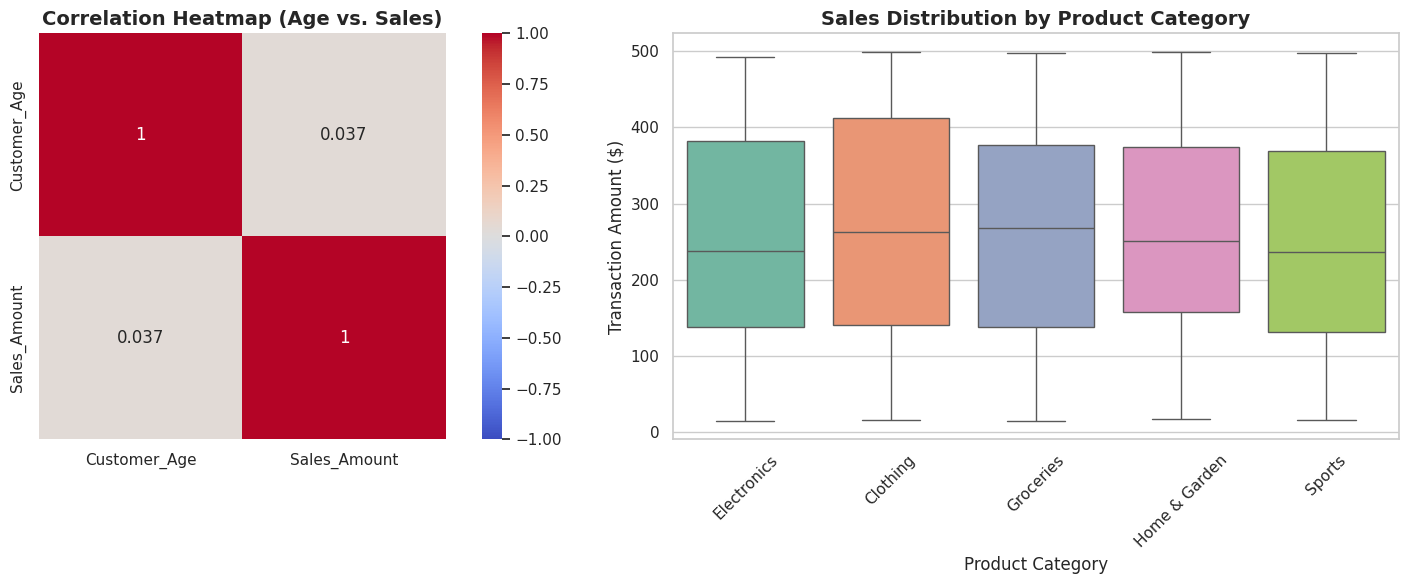

In [9]:
# 1. Select only the numerical columns to find their correlation
numeric_cols = df[['Customer_Age', 'Sales_Amount']]
correlation_matrix = numeric_cols.corr()

# 2. Set up the layout for the final two charts
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Chart A: Correlation Heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, ax=axes[0], square=True)
axes[0].set_title('Correlation Heatmap (Age vs. Sales)', fontsize=14, fontweight='bold')

# Chart B: Additional Insight - Sales Spread by Category (Boxplot)
sns.boxplot(x='Product_Category', y='Sales_Amount', data=df, ax=axes[1], palette='Set2', hue='Product_Category', legend=False)
axes[1].set_title('Sales Distribution by Product Category', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Product Category')
axes[1].set_ylabel('Transaction Amount ($)')
axes[1].tick_params(axis='x', rotation=45) # Tilts the text so it's easy to read

plt.tight_layout()
plt.show()

Observation 5: Correlation & Distribution Insights
The correlation heatmap indicates a correlation coefficient near zero between Customer Age and Sales Amount, meaning a customer's age does not dictate how much they spend per transaction. Additionally, the boxplot provides a non-obvious insight into our product categories: despite variations in total revenue, the median transaction size and overall spread of purchase amounts are remarkably consistent across all categories, with no extreme outliers skewing the data.

Conclusion & Business Recommendations
Based on the exploratory data analysis, here are three actionable recommendations for the business:

Demographic-Agnostic Marketing: Since the data shows an even gender split and zero correlation between age and transaction size, marketing budgets should not be hyper-targeted to a narrow demographic. Instead, campaigns should focus on broad appeal and product utility to capture the widest audience.

Implement Cross-Selling in High-Volume Categories: Because the median transaction size is similar across all categories, the best way to increase revenue is to increase the number of items per cart. We should implement bundle discounts (e.g., "Buy a Clothing item, get 15% off an Accessory") to drive up the average order value.

Stabilize Quarterly Volatility: The time series analysis revealed distinct peaks and valleys in quarterly revenue. To combat the slower months, the business should deploy targeted email retention campaigns and limited-time seasonal sales slightly before the historical dip periods to stabilize cash flow.